# Phase 5 — Feature engineering : carnet de travail

**Rôle de ce carnet.** C'est le carnet de travail de la phase 5 : il montre, résultats à l'appui, comment
le jeu d'apprentissage a été figé, découpé et validé. Les conclusions sont **reportées** dans le notebook de
certification (§ 7.7 et § 8.A), qui reste la preuve remise au jury (règle 4, révisée le 02/10/2026).

**Ce que couvre cette version.**

| Bloc | Contenu | État |
|---|---|---|
| Règles | Arbitrages et règles de décision, fixés le 01/10 **avant** tout résultat | ✅ |
| 0 · Préalables | Catalogue réduit à `plan`, diagnostic de la valeur vie client, sobriété du calcul | ✅ |
| A · Séparer et valider | Découpage enregistré, stabilité des variables, validation adverse, test de permutation, courbes d'apprentissage | ✅ |
| B · Apport des variables construites | Validation croisée 5 × 5, courbes appariées, ablation par groupe | à venir |
| C · Sélection des variables | Importance par permutation, plancher des leurres, liste figée | à venir |

**Comment le lire.** Chaque sous-section pose une question, y répond par une mesure, puis compare la mesure à
la règle fixée d'avance. Le code n'est écrit qu'une fois, dans `src/churn_saas/` ; ce carnet l'importe et
l'affiche quand il l'explique (règle 7).

In [1]:
# --- Environment ---------------------------------------------------------------------
import sys
import time
import tomllib
from pathlib import Path

RACINE = Path.cwd()
for candidat in [RACINE, *RACINE.parents]:
    if (candidat / "src" / "churn_saas").is_dir():
        RACINE = candidat
        sys.path.insert(0, str(candidat / "src"))
        break

import matplotlib.pyplot as plt
import pandas as pd

from churn_saas.config import FICHIER_CATALOGUE, FICHIER_COMPLET, FICHIER_RESSOURCES
from churn_saas.features import executer_pipeline
from churn_saas.notebook import afficher_source, afficher_tableau

pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

resultat = executer_pipeline(FICHIER_COMPLET, FICHIER_CATALOGUE)
silver, X, y = resultat.silver, resultat.X, resultat.y.astype(int)
print(f"Jeu gold : {X.shape[0]} comptes × {X.shape[1]} variables explicatives, churn {y.mean():.1%}")

Jeu gold : 5000 comptes × 25 variables explicatives, churn 28.0%


## 1. Les règles du jeu, fixées avant les résultats

Une règle fixée après coup s'ajuste au résultat qu'elle prétend départager (règle de travail 8). Les
arbitrages et les seuils ci-dessous ont été arrêtés le 01/10/2026, avant d'entraîner le moindre modèle ; ils
sont détaillés dans `docs/00.README_choix_methodologiques.md` § 7 bis.

| Arbitrage | Décision | Critère décisif |
|---|---|---|
| Découpage | Test de 20 % sous scellés, validation croisée stratifiée 5 × 5 | Un jeu de validation fixe (≈ 280 départs) ne départagerait pas des écarts de 1 à 2 points |
| Catalogue | `plan` seul | Une seule valeur par formule ; plus de dépendance au référentiel en production |
| Valeur vie client | Diagnostic d'abord | Ne pas gonfler l'impact mesuré si elle encode l'issue |
| Hyperparamètres | `GridSearchCV` (44 combinaisons) | Optuna n'apporte rien sur un si petit espace |
| Empreinte | Temps mesurés et convertis | CodeCarbon : mesure sans effet sur aucune décision |
| Leurres | Retirés du modèle final après la sélection | Ils mesurent le bruit, puis n'apportent que du bruit |

Les seuils chiffrés vivent dans la configuration du projet : le tableau suivant les y lit, il ne les recopie pas.

In [2]:
# --- Decision thresholds, read from the project configuration ---------------------------
from churn_saas import config

regles = pd.DataFrame([
    ("Stratification : écart de taux de churn entre entraînement et test",
     f"< {config.ECART_STRATIFICATION_MAX_PTS} point"),
    ("Stabilité de chaque variable (PSI)", f"< {config.SEUIL_PSI_DECOUPAGE}"),
    ("Validation adverse : AUC d'un modèle qui distingue entraînement et test",
     f"< {config.SEUIL_AUC_ADVERSE}"),
    ("Test de permutation : p-valeur", f"< {config.SEUIL_P_PERMUTATION}"),
    ("Courbe d'apprentissage", "courbes qui se rejoignent et plafonnent"),
    ("Garder une variable construite", "gain de PR-AUC > 1 écart-type entre plis (bloc B)"),
    ("Retirer une variable", "sous le plancher des leurres et sans perte > 1 écart-type (bloc C)"),
], columns=["Décision", "Règle"])
afficher_tableau(regles, titre="Règles de décision de la phase 5")

Décision,Règle
Stratification : écart de taux de churn entre entraînement et test,< 1.0 point
Stabilité de chaque variable (PSI),< 0.1
Validation adverse : AUC d'un modèle qui distingue entraînement et test,< 0.6
Test de permutation : p-valeur,< 0.05
Courbe d'apprentissage,courbes qui se rejoignent et plafonnent
Garder une variable construite,gain de PR-AUC > 1 écart-type entre plis (bloc B)
Retirer une variable,sous le plancher des leurres et sans perte > 1 écart-type (bloc C)


## 2. Bloc 0 — Préalables

### 2.1 Le catalogue réduit à `plan`

**Question.** Les colonnes apportées par le catalogue (prix par siège, SLA, quota, support dédié) et
`fonctionnalites_total` disent-elles autre chose que la formule d'abonnement ?

In [3]:
# --- One value per plan? ----------------------------------------------------------------
from churn_saas.config import EXCLUES_ATTRIBUT_FORMULE
from churn_saas.donnees import table_exclusions

valeurs_par_plan = silver[["plan", *EXCLUES_ATTRIBUT_FORMULE]].drop_duplicates().sort_values(
    "prix_mensuel_par_siege_eur")
afficher_tableau(valeurs_par_plan, titre="Attributs de chaque formule, tels que les données les portent")
distinctes = silver.groupby("plan")[EXCLUES_ATTRIBUT_FORMULE].nunique().max()
print("Nombre maximal de valeurs distinctes par formule :", distinctes.to_dict())

exclusions = table_exclusions()
afficher_tableau(exclusions[exclusions["colonne"].isin(EXCLUES_ATTRIBUT_FORMULE)],
                 titre="Exclusions de la phase 5, avec leur motif")

plan,prix_mensuel_par_siege_eur,sla_reponse_h,quota_stockage_go,support_dedie,fonctionnalites_total
Starter,12,24,10,Non,8
Pro,25,12,100,Non,16
Business,45,6,500,Oui,26
Enterprise,80,3,2000,Oui,40


Nombre maximal de valeurs distinctes par formule : {'prix_mensuel_par_siege_eur': 1, 'sla_reponse_h': 1, 'quota_stockage_go': 1, 'support_dedie': 1, 'fonctionnalites_total': 1}


colonne,motif d'exclusion
fonctionnalites_total,"attribut de la formule — une seule valeur par plan, information portée par `plan`"
prix_mensuel_par_siege_eur,"attribut de la formule — une seule valeur par plan, information portée par `plan`"
quota_stockage_go,"attribut de la formule — une seule valeur par plan, information portée par `plan`"
sla_reponse_h,"attribut de la formule — une seule valeur par plan, information portée par `plan`"
support_dedie,"attribut de la formule — une seule valeur par plan, information portée par `plan`"


**Lecture.** Quatre lignes, une par formule : chaque attribut ne prend **qu'une valeur par plan**. Gardées, ces
cinq colonnes donnaient au modèle six fois la même information à quatre valeurs — une colinéarité parfaite
qui rend illisibles les coefficients d'une régression logistique. Elles sont exclues au passage au gold ; le
catalogue reste utile pour reconstruire le revenu manquant (§ 7.4 du notebook de certification).

**Effet.** Le gold passe de 31 à 26 colonnes, soit 25 variables explicatives. Le modèle ne dépend plus du
référentiel des plans en production (scénario de perte du catalogue). Un test garde la prémisse : si une
formule prenait un jour deux prix, il échouerait.

### 2.2 La valeur vie client encode-t-elle l'issue ?

**Question.** La règle de décision pondère chaque compte par sa valeur vie client. Exprimée en mois de revenu,
elle vaut 18,9 mois chez les comptes qui restent, 15,6 chez ceux qui partent. Si elle avait été calculée en
connaissant la durée de vie réelle, l'impact mesuré en phase 9 serait gonflé.

**Méthode.** Expliquer la valeur par les variables connues **avant** la décision, puis par les mêmes plus
l'issue. Si l'issue apporte une information propre, la variance expliquée augmente. Seuils de lecture fixés
avant le calcul : gain de R² < 0,01 et effet < 10 %.

indicateur,valeur
Comptes analysés,4850.000
"Mois de revenu, comptes qui restent (médiane)",18.860
"Mois de revenu, comptes qui partent (médiane)",15.580
"Ancienneté, comptes qui restent (mois, médiane)",12.000
"Ancienneté, comptes qui partent (mois, médiane)",6.000
"Variance expliquée sans l'issue (R², validation croisée)",0.895
"Variance expliquée avec l'issue (R², validation croisée)",0.895
Gain de R² apporté par l'issue,0.000
"Effet de l'issue sur la valeur, à variables égales (%)",3.440
La valeur encode-t-elle l'issue ?,0.000


La valeur encode-t-elle l'issue ? non


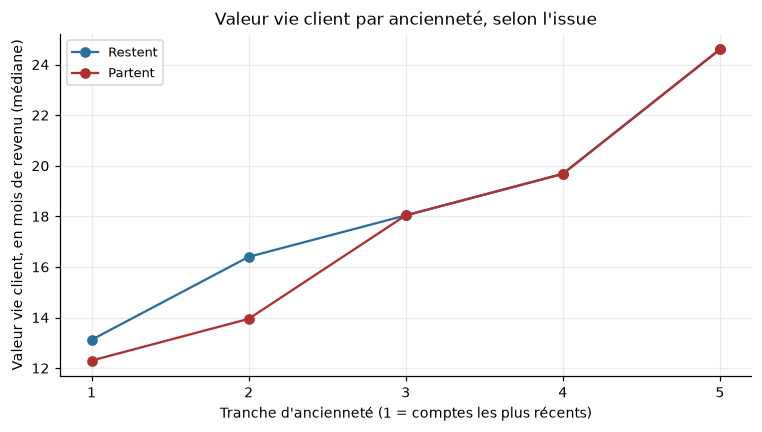

In [4]:
# --- Diagnostic of the lifetime value ---------------------------------------------------
from churn_saas.evaluation import diagnostiquer_valeur_vie, valeur_encode_l_issue
from churn_saas.features import tracer_valeur_vie_par_anciennete

diagnostic = diagnostiquer_valeur_vie(
    X.select_dtypes("number"),
    silver["valeur_vie_client_eur"],
    silver["revenu_mensuel_recurrent_eur"],
    silver["churn"],
    silver["anciennete_mois"],
)
afficher_tableau(diagnostic.round(3), titre="La valeur vie client, expliquée sans puis avec l'issue")
print("La valeur encode-t-elle l'issue ?", "oui" if valeur_encode_l_issue(diagnostic) else "non")

tracer_valeur_vie_par_anciennete(silver)
plt.show()

**Lecture.** Sans l'issue, les variables connues avant la décision expliquent près de 90 % de la variance de
la valeur ; avec l'issue, **pas davantage**. La figure montre l'essentiel : la valeur croît avec
l'ancienneté, et les deux courbes **se confondent dès la troisième tranche**. L'écart global vient surtout de
la **composition** des groupes — les comptes qui partent ont 6 mois d'ancienneté médiane, ceux qui restent 12.
Dans les deux premières tranches, les comptes qui partent restent un peu en dessous (de 1 à 2,4 mois de
revenu) ; cet écart résiduel est expliqué par d'autres variables connues avant la décision, puisque l'issue
n'ajoute rien à la variance expliquée.

**Décision.** La valeur observée évaluera la règle de décision ; l'évaluation par une valeur prédite est
écartée (registre, E-508). Un test rejoue ce diagnostic sur chaque jeu.

### 2.3 La sobriété du calcul, chiffrée sur le poste

**Question.** Faut-il un outil dédié pour mesurer l'empreinte du calcul ? Les ressources du poste de
développement et les temps mesurés sont une **entrée du projet** (`config/ressources_poste.toml`).

Poste : Intel(R) Core(TM) i5-6300U CPU @ 2.40GHz, 4 cœurs logiques, 34.2 Go — mesuré le 2026-10-02 (poste de développement)


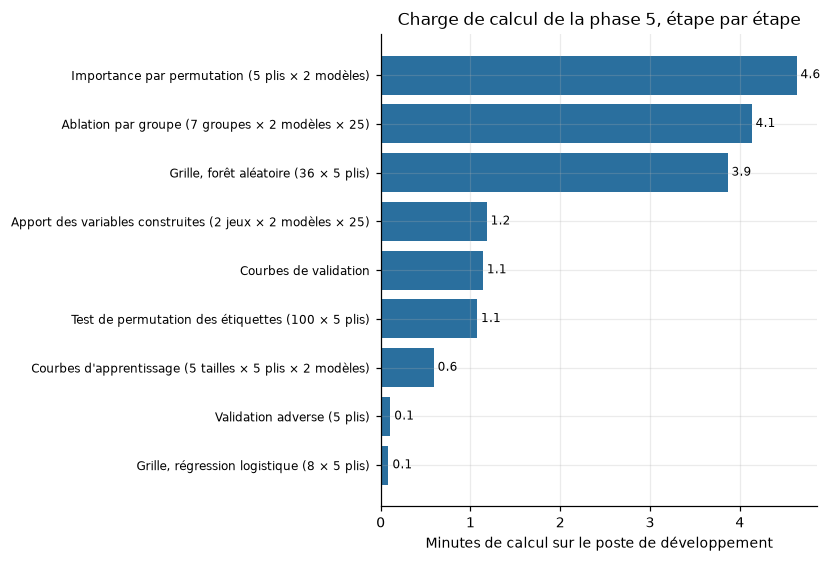

hypothèse,puissance (W),énergie par exécution (Wh),"énergie, 10 exécutions (Wh)","CO₂e, 10 exécutions (g)"
basse,15,4.2,42.0,1.27
haute,25,7.0,70.0,2.11


In [5]:
# --- Compute footprint, from the project input ---------------------------------------------
from churn_saas.features import tracer_charge_calcul
from churn_saas.modelisation import CHARGE_PHASE5, estimer_charge, table_empreinte

with open(FICHIER_RESSOURCES, "rb") as flux:
    ressources = tomllib.load(flux)
poste, hypotheses = ressources["poste"], ressources["hypotheses"]
print(f"Poste : {poste['processeur']}, {poste['coeurs_logiques']} cœurs logiques, "
      f"{poste['memoire_go']} Go — mesuré le {ressources['source']['date']} "
      f"({ressources['source']['origine']})")

charge = estimer_charge(ressources["mesures"], CHARGE_PHASE5)
tracer_charge_calcul(charge)
plt.show()

total = float(charge["secondes"].sum())
afficher_tableau(
    table_empreinte(total, {"basse": hypotheses["puissance_basse_w"],
                            "haute": hypotheses["puissance_haute_w"]},
                    hypotheses["intensite_carbone_g_kwh"],
                    int(hypotheses["executions_developpement"])),
    titre=f"Empreinte de la phase 5 : {total / 60:.0f} minutes de calcul par exécution complète",
)

**Lecture.** Toute la phase 5 représente un quart d'heure de calcul sur le portable, dominé par l'importance
par permutation, l'ablation et la grille de la forêt aléatoire ; dix exécutions complètes émettent un à deux grammes de CO₂e. Aucun arbitrage
ne se joue à cette échelle : CodeCarbon est écarté, et ce carnet **chronomètre** ses propres étapes de calcul
ci-dessous, pour que le chiffrage reste vérifiable (registre, E-502 ; document généré
`docs/06.SOBRIETE_calcul.md`).

## 3. Bloc A — Séparer le jeu, puis valider la séparation et le jeu

### 3.1 Le découpage, enregistré au manifeste

Le jeu de test est mis de côté **une fois** et ne servira **qu'une fois**, pour l'évaluation finale. Aucun
seuil, aucune variable, aucun réglage ne sera choisi dessus. La validation se fait par validation croisée
à l'intérieur des 80 % d'entraînement.

In [6]:
# --- The split, as the manifest records it ---------------------------------------------------
import json

from churn_saas.donnees import decouper_entrainement_test, resume_decoupage
from churn_saas.features import parties_du_decoupage, verifier_decoupage

afficher_source(decouper_entrainement_test)
parties = parties_du_decoupage(resultat)
afficher_tableau(resume_decoupage(parties), titre="Les deux parties et leur taux de churn")

manifeste = json.loads((RACINE / "data" / "manifeste_v1.0.json").read_text(encoding="utf-8"))
afficher_tableau(verifier_decoupage(resultat, manifeste),
                 titre="Le découpage recalculé est-il celui que le manifeste enregistre ?")

**Source — `churn_saas.donnees.gold.decouper_entrainement_test`**

```python
def decouper_entrainement_test(
    X: pd.DataFrame, y: pd.Series, part_test: float = PART_TEST, graine: int = GRAINE
) -> Decoupage:
    """Stratified split: the test part is set aside once and used once (arbitrage 1).

    Stratified on the target so both parts keep the 28 % churn rate; seeded so the very
    same accounts land in the test part on every machine. Validation happens inside the
    training part, by cross-validation - there is no fixed validation set (choix § 7 bis).
    """
    X_a, X_t, y_a, y_t = train_test_split(
        X, y, test_size=part_test, stratify=y, random_state=graine
    )
    return Decoupage(X_a, X_t, y_a, y_t, part_test, graine)

```

partie,comptes,taux de churn (%),conforme
entraînement,4000.0,28.0,NaN
test,1000.0,28.0,NaN
écart (points),NaN,0.0,True


élément,enregistré,recalculé,conforme
graine,—,42,False
part_test,—,0.2,False
stratifie_sur,—,churn,False
comptes_entrainement,—,4000,False
comptes_test,—,1000,False
taux_churn_entrainement,—,0.28,False
taux_churn_test,—,0.28,False
empreinte_comptes_test,—,c0e443d62fa63a85b1b8,False
empreinte_entrainement,—,c3500a53a3217c4115f9,False
empreinte_test,—,715b8d8aa8044f260642,False


**Lecture.** 4 000 comptes d'entraînement, 1 000 de test, 28,0 % de churn de part et d'autre : la
stratification est exacte. Le manifeste enregistre la graine, la part, les effectifs et les **empreintes** de
chaque partie et de la liste des comptes de test. Si une graine, une donnée ou une ligne de code déplace un
seul compte, un test le signale avant qu'un résultat ne soit comparé à un autre.

### 3.2 Chaque variable a-t-elle la même distribution dans les deux parties ?

L'indice de stabilité (PSI) compare la répartition de chaque variable entre entraînement et test ; c'est le
même outil qui surveillera la dérive en production (phase 11). Il est appliqué ici aux 25 variables, dont 7
catégorielles.

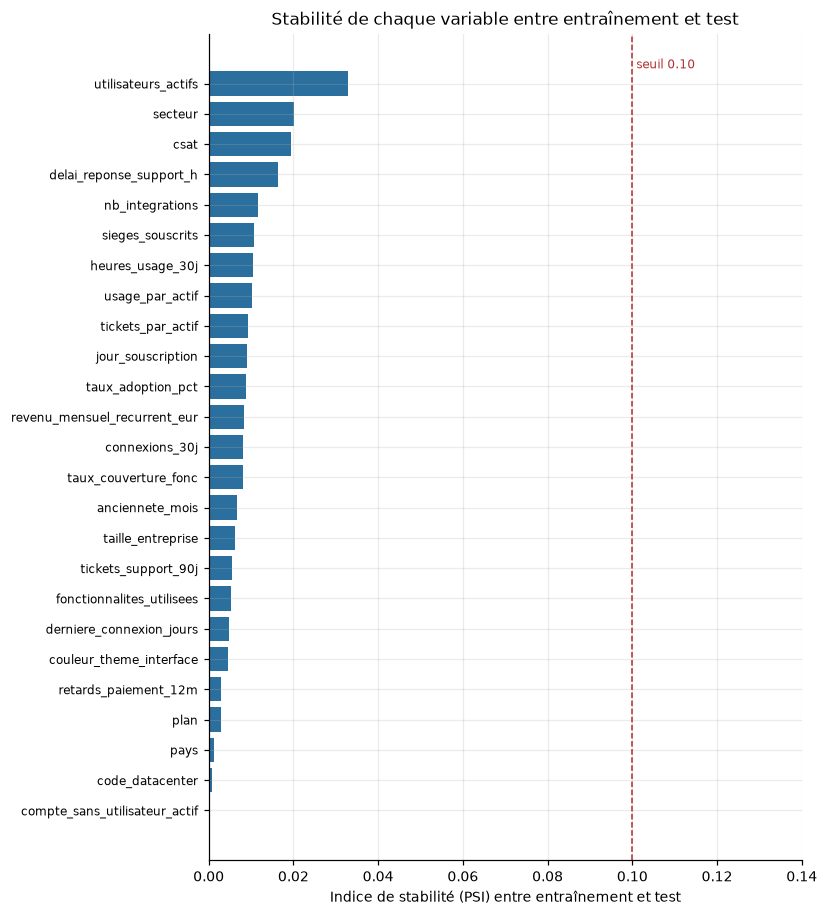

PSI maximal : 0.033 (utilisateurs_actifs) — 0 variable(s) au-dessus du seuil de 0.1


In [7]:
# --- Stability of each variable between the parts ------------------------------------------
from churn_saas.config import SEUIL_PSI_DECOUPAGE
from churn_saas.features import tracer_psi
from churn_saas.monitoring import rapport_derive

rapport = rapport_derive(parties.X_entrainement, parties.X_test, list(X.columns), SEUIL_PSI_DECOUPAGE)
tracer_psi(rapport, SEUIL_PSI_DECOUPAGE)
plt.show()
print(f"PSI maximal : {rapport['psi'].max():.3f} ({rapport.iloc[0]['variable']}) — "
      f"{int(rapport['alerte'].sum())} variable(s) au-dessus du seuil de {SEUIL_PSI_DECOUPAGE}")

**Lecture.** Le PSI le plus élevé reste plus de trois fois sous le seuil : aucune variable ne se distribue
différemment dans le jeu de test.

**Un défaut silencieux trouvé en chemin.** Jusqu'à cette phase, le rapport de dérive appliquait l'indice
numérique à toutes les colonnes. Sur une variable catégorielle, il renvoyait une valeur manquante — et une
valeur manquante comparée au seuil se lit « aucune alerte ». Un secteur passant de 50/50 à 95/5 aurait été
rapporté stable. Les variables catégorielles ont maintenant leur propre indice, et un test le garantit.

### 3.3 Un modèle peut-il distinguer l'entraînement du test ?

**Validation adverse.** On mélange les deux parties, on marque chaque ligne de son origine, et on demande à
une forêt aléatoire de retrouver cette origine. Une AUC proche de 0,5 signifie qu'elle n'y arrive pas.

AUC adverse : 0.518 (règle : < 0.6) — calcul : 10 s


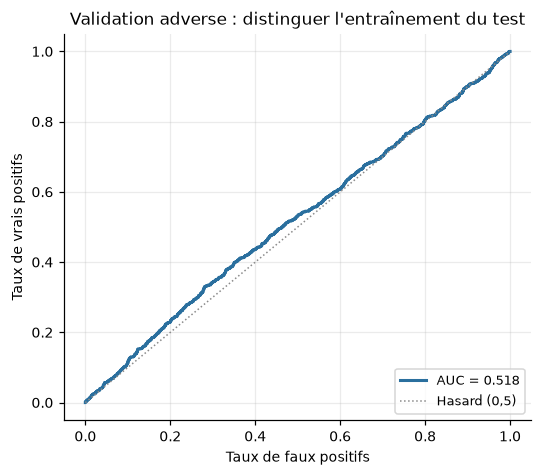

In [8]:
# --- Adversarial validation -------------------------------------------------------------------
from churn_saas.config import SEUIL_AUC_ADVERSE
from churn_saas.features import tracer_validation_adverse
from churn_saas.modelisation import construire_candidat, validation_adverse

debut = time.perf_counter()
adverse = validation_adverse(construire_candidat(X, equilibrer=False),
                             parties.X_entrainement, parties.X_test)
print(f"AUC adverse : {adverse['auc']:.3f} (règle : < {SEUIL_AUC_ADVERSE}) — "
      f"calcul : {time.perf_counter() - debut:.0f} s")
tracer_validation_adverse(adverse["taux_faux_positifs"], adverse["taux_vrais_positifs"], adverse["auc"])
plt.show()

**Lecture.** La courbe suit la diagonale du hasard : le classifieur ne distingue pas les deux parties. Le jeu
de test mesure donc bien ce qu'il prétend mesurer. Le contrôle **peut** échouer — un test unitaire le montre
sur un décalage artificiel — ce qui donne un sens à sa réussite.

### 3.4 Le modèle bat-il des étiquettes tirées au hasard ?

**Test de permutation.** On mélange les étiquettes cent fois et on réentraîne la régression logistique à
chaque fois, en validation croisée. Si le modèle faisait aussi bien sur le hasard que sur les vraies
étiquettes, c'est que la réponse se serait glissée dans la chaîne de préparation — une fuite.

PR-AUC réelle 0.789 ; étiquettes mélangées : moyenne 0.285, maximum 0.313 ; p = 0.010 — calcul : 109 s


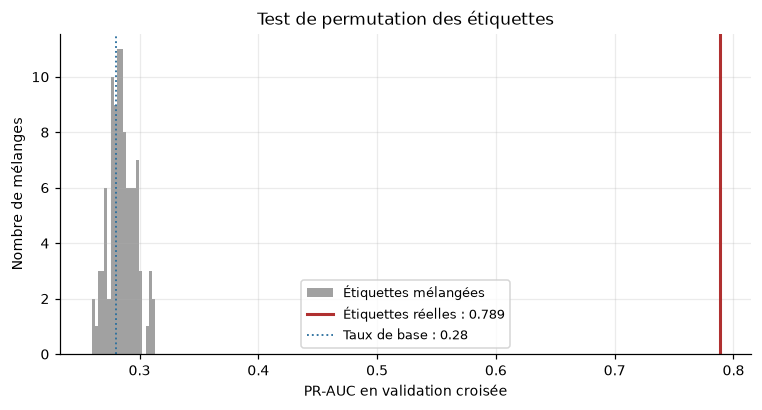

In [9]:
# --- Label permutation test ----------------------------------------------------------------
from churn_saas.features import tracer_permutation
from churn_saas.modelisation import construire_baseline, tester_permutation

debut = time.perf_counter()
permutation = tester_permutation(construire_baseline(X), parties.X_entrainement,
                                 parties.y_entrainement, n_permutations=100)
print(f"PR-AUC réelle {permutation['score']:.3f} ; étiquettes mélangées : moyenne "
      f"{permutation['moyenne_permutee']:.3f}, maximum {permutation['scores_permutes'].max():.3f} ; "
      f"p = {permutation['p_valeur']:.3f} — calcul : {time.perf_counter() - debut:.0f} s")
tracer_permutation(permutation["scores_permutes"], permutation["score"],
                   float(parties.y_entrainement.mean()))
plt.show()

**Lecture.** Sur des étiquettes mélangées, le modèle plafonne au niveau du taux de base (0,28) ; sur les
vraies, il atteint 0,79. Aucun des cent mélanges n'approche ce score : p = 0,01, le plus petit possible avec
cent mélanges. **La chaîne ne fuit pas** : le modèle apprend des données.

### 3.5 Le jeu suffit-il, et les modèles sur-apprennent-ils ?

**Courbes d'apprentissage.** La performance est mesurée en entraînement et en validation pour des tailles
croissantes du jeu d'entraînement. Deux lectures : si la validation plafonne, ajouter des données n'aiderait
pas ; si l'entraînement reste loin au-dessus de la validation, le modèle apprend par cœur.

Calcul des deux courbes : 48 s


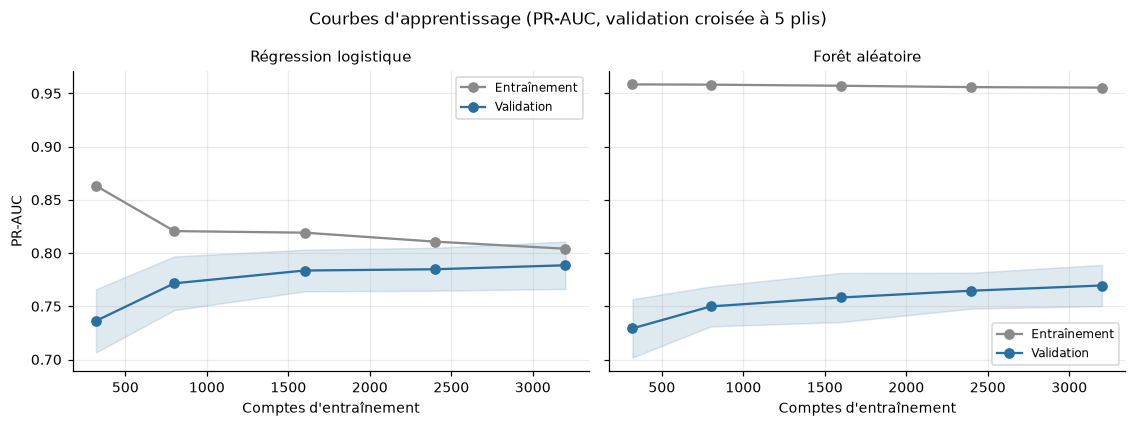

comptes d'entraînement,PR-AUC entraînement,PR-AUC validation,écart-type validation,écart entraînement - validation
320,0.863,0.736,0.030,0.127
800,0.821,0.772,0.025,0.049
1600,0.819,0.784,0.020,0.036
2400,0.811,0.785,0.020,0.026
3200,0.804,0.789,0.022,0.016


comptes d'entraînement,PR-AUC entraînement,PR-AUC validation,écart-type validation,écart entraînement - validation
320,0.958,0.729,0.027,0.229
800,0.958,0.750,0.019,0.208
1600,0.957,0.758,0.023,0.199
2400,0.956,0.765,0.017,0.191
3200,0.955,0.770,0.019,0.186


In [10]:
# --- Learning curves of both models ------------------------------------------------------------
from churn_saas.features import tracer_courbes_apprentissage
from churn_saas.modelisation import courbe_apprentissage

debut = time.perf_counter()
courbes = {
    "Régression logistique": courbe_apprentissage(construire_baseline(X), parties.X_entrainement,
                                                  parties.y_entrainement),
    "Forêt aléatoire": courbe_apprentissage(construire_candidat(X), parties.X_entrainement,
                                            parties.y_entrainement),
}
print(f"Calcul des deux courbes : {time.perf_counter() - debut:.0f} s")
tracer_courbes_apprentissage(courbes)
plt.show()
for nom, courbe in courbes.items():
    afficher_tableau(courbe.round(3), titre=f"Courbe d'apprentissage — {nom}")

**Lecture — régression logistique.** La validation monte de 0,74 à 0,79 puis **plafonne dès 1 600 comptes** ;
l'entraînement redescend à sa rencontre, à 0,016 d'écart. Le modèle a convergé : 5 000 comptes suffisent.

**Lecture — forêt aléatoire.** La validation monte lentement (0,73 → 0,77), mais l'entraînement reste
**collé à 0,96** : l'écart de 0,19 ne se resserre pas. La forêt **apprend par cœur** l'entraînement. Avec
`min_samples_leaf=5` et une profondeur illimitée, chaque arbre isole presque chaque compte. C'est un défaut de
**régularisation**, pas un manque de données : la grille d'hyperparamètres (phase 7) explore
`min_samples_leaf` jusqu'à 20 et `max_depth` à 10 et 20, et la courbe de la forêt devra être retracée avec
le réglage retenu.

À ce stade, la régression logistique, plus simple, valide mieux que la forêt (0,79 contre 0,77). Ce n'est
pas encore une conclusion : la forêt n'a pas été réglée. C'est l'objet de la comparaison de la phase 6.

### 3.6 Synthèse des verdicts

In [11]:
# --- Every check against the rule fixed beforehand ----------------------------------------------
ecart_strat = abs(parties.y_entrainement.mean() - parties.y_test.mean()) * 100
lr, foret = courbes["Régression logistique"].iloc[-1], courbes["Forêt aléatoire"].iloc[-1]
synthese = pd.DataFrame([
    ("Stratification", f"écart {ecart_strat:.1f} point", f"< {config.ECART_STRATIFICATION_MAX_PTS}",
     ecart_strat < config.ECART_STRATIFICATION_MAX_PTS),
    ("Stabilité (PSI maximal)", f"{rapport['psi'].max():.3f}", f"< {SEUIL_PSI_DECOUPAGE}",
     not rapport["alerte"].any()),
    ("Validation adverse (AUC)", f"{adverse['auc']:.3f}", f"< {SEUIL_AUC_ADVERSE}", adverse["conforme"]),
    ("Test de permutation (p)", f"{permutation['p_valeur']:.3f}", f"< {config.SEUIL_P_PERMUTATION}",
     permutation["conforme"]),
    ("Convergence, régression", f"écart {lr['écart entraînement - validation']:.3f}",
     "courbes qui se rejoignent", lr["écart entraînement - validation"] < 0.05),
    ("Convergence, forêt", f"écart {foret['écart entraînement - validation']:.3f}",
     "courbes qui se rejoignent", foret["écart entraînement - validation"] < 0.05),
], columns=["Contrôle", "Mesure", "Règle", "Conforme"])
afficher_tableau(synthese, titre="Bloc A : la séparation et le jeu, contre les règles fixées le 01/10")

Contrôle,Mesure,Règle,Conforme
Stratification,écart 0.0 point,< 1.0,True
Stabilité (PSI maximal),0.033,< 0.1,True
Validation adverse (AUC),0.518,< 0.6,True
Test de permutation (p),0.010,< 0.05,True
"Convergence, régression",écart 0.016,courbes qui se rejoignent,True
"Convergence, forêt",écart 0.186,courbes qui se rejoignent,False


**Bilan du bloc A.** Cinq contrôles sur six sont conformes : la séparation est représentative, la chaîne ne
fuit pas, le jeu suffit. Le sixième n'invalide pas le jeu : il signale que la forêt doit être régularisée
avant d'être comparée à la régression.

## 4. Journal de bord de la phase 5 (blocs 0 et A)

**Décisions.**
- Cinq attributs de formule exclus au profit de `plan` (arbitrage 2) ; gold à 26 colonnes.
- La valeur vie client observée évaluera la règle de décision : elle n'encode pas l'issue (arbitrage 3).
- Découpage 80/20 stratifié, graine 42, **enregistré au manifeste** ; validation par validation croisée
  dans l'entraînement (arbitrage 1).
- Optuna et CodeCarbon écartés ; MLflow différé à la phase 10 ; leurres retirés du modèle final après la
  sélection.

**Problèmes rencontrés et corrections.**
- Le rapport de dérive ignorait en silence les variables catégorielles : corrigé, et testé.
- Le manifeste ne pouvait être rafraîchi qu'en ré-exécutant le carnet 03 ; quand Jupyter a cessé de démarrer
  (paquet `orjson` partiellement désinstallé par un `uv sync`), le manifeste ne pouvait plus suivre le code. La
  matérialisation a désormais sa propre commande, sans Jupyter : `make materialiser`.
- Mesures de sobriété d'abord prises dans l'environnement de l'assistant, puis remplacées par celles du
  portable de développement ; la mémoire est affichée en Go et en Gio pour éviter un « 34 Go » trompeur sur
  une machine de 32 Go.

**Prochaines étapes.**
- **Bloc B** : apport réel des variables construites — validation croisée 5 × 5 avec et sans elles, courbes
  appariées par pli, ablation par groupe de variables.
- **Bloc C** : sélection — importance par permutation contre le plancher des leurres, liste figée, retraits
  motivés au registre.